# Data sharpening:

In [1]:
import cv2
from PIL import Image, ImageEnhance
import os

# Define the root input folder
input_root = r'C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\labeled_data_all'

# Define the root output folder for enhanced images
output_root = r'C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\enhanced_images_all'

# Create the output root folder if it doesn't exist
if not os.path.exists(output_root):
    os.makedirs(output_root)

In [2]:
def enhance_image(image_path, output_path):
    # Read image using OpenCV
    image = cv2.imread(image_path)
    
    # Denoise the image
    denoised_img = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)
    
    # Convert to PIL image for sharpening and contrast adjustment
    pil_img = Image.fromarray(cv2.cvtColor(denoised_img, cv2.COLOR_BGR2RGB))
    
    # Sharpen the image
    sharpness_enhancer = ImageEnhance.Sharpness(pil_img)
    sharpened_img = sharpness_enhancer.enhance(2.0)
    
    # Increase contrast
    contrast_enhancer = ImageEnhance.Contrast(sharpened_img)
    contrast_img = contrast_enhancer.enhance(1.5)
    
    # Save the enhanced image
    contrast_img.save(output_path)

# Recursively process all files in the input directory
for root, dirs, files in os.walk(input_root):
    # Create corresponding output folder
    output_dir = root.replace(input_root, output_root)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Process each image file in the current directory
    for file in files:
        if file.endswith('.jpg') or file.endswith('.png'):
            input_img_path = os.path.join(root, file)
            output_img_path = os.path.join(output_dir, file)
            enhance_image(input_img_path, output_img_path)

print(f"Image enhancement complete. Enhanced images saved in {output_root}.")

Image enhancement complete. Enhanced images saved in C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\enhanced_images_all.


# Data pre-processing for YOLO:

In [3]:
import cv2
import os

# Define the input and output folders
input_root = r'C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\enhanced_images_all'
output_root = r'C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\preprocessed_images_all'

# Create output folder if it doesn't exist
if not os.path.exists(output_root):
    os.makedirs(output_root)

In [4]:
# Function to preprocess the image using CLAHE and normalization
def preprocess_image(image_path, output_path):
    image = cv2.imread(image_path)

    # Apply Gaussian blur (optional, reduce if it's causing issues)
    blurred_img = cv2.GaussianBlur(image, (3, 3), 0)

    # Convert to LAB color space (for applying CLAHE)
    lab_img = cv2.cvtColor(blurred_img, cv2.COLOR_BGR2LAB)
    
    # Split the LAB image into its components
    l_channel, a, b = cv2.split(lab_img)
    
    # Apply CLAHE to the L-channel (brightness)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl_img = clahe.apply(l_channel)
    
    # Merge the CLAHE enhanced L-channel back with the A and B channels
    merged_img = cv2.merge((cl_img, a, b))
    
    # Convert back to BGR color space
    final_img = cv2.cvtColor(merged_img, cv2.COLOR_LAB2BGR)
    
    # Save the preprocessed image
    cv2.imwrite(output_path, final_img)

# Recursively process all images in the input folder
for root, dirs, files in os.walk(input_root):
    output_dir = root.replace(input_root, output_root)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    for file in files:
        if file.endswith('.jpg') or file.endswith('.png'):
            input_img_path = os.path.join(root, file)
            output_img_path = os.path.join(output_dir, file)
            preprocess_image(input_img_path, output_img_path)

print(f"Preprocessing complete. Check the 'preprocessed_images_all' folder.")

Preprocessing complete. Check the 'preprocessed_images_all' folder.


# Isolated sutures

In [5]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

# Define the root input folder
input_root = r'C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\enhanced_images_all'

# Define the root output folder for isolated sutures
output_root = r'C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\isolated_sutures'

# Create the output root folder if it doesn't exist
if not os.path.exists(output_root):
    os.makedirs(output_root)

# Function to isolate sutures from an image
def isolate_sutures(image_path, output_path):
    # Load the image
    image = cv2.imread(image_path)

    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Otsu's thresholding
    _, thresh_image = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Apply morphological operations (closing)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    cleaned_image = cv2.morphologyEx(thresh_image, cv2.MORPH_CLOSE, kernel)

    # Find contours
    contours, _ = cv2.findContours(cleaned_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Create an empty mask where we'll draw the contours
    mask = np.zeros_like(gray_image)

    # Draw the contours on the mask
    cv2.drawContours(mask, contours, -1, (255), thickness=cv2.FILLED)

    # Use the mask to extract sutures from the original image
    suture_extracted = cv2.bitwise_and(image, image, mask=mask)

    # Save the final isolated sutures image
    cv2.imwrite(output_path, suture_extracted)

# Recursively traverse through the input folder and process all images
for root, dirs, files in os.walk(input_root):
    # Create corresponding output folder
    output_dir = root.replace(input_root, output_root)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Process each image file in the current directory
    for file in files:
        if file.endswith('.jpg') or file.endswith('.png'):
            input_img_path = os.path.join(root, file)
            output_img_path = os.path.join(output_dir, file)
            isolate_sutures(input_img_path, output_img_path)

print(f"Suture isolation complete. Isolated suture images saved in '{output_root}' folder.")


Suture isolation complete. Isolated suture images saved in 'C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\isolated_sutures' folder.


## Test image PP step

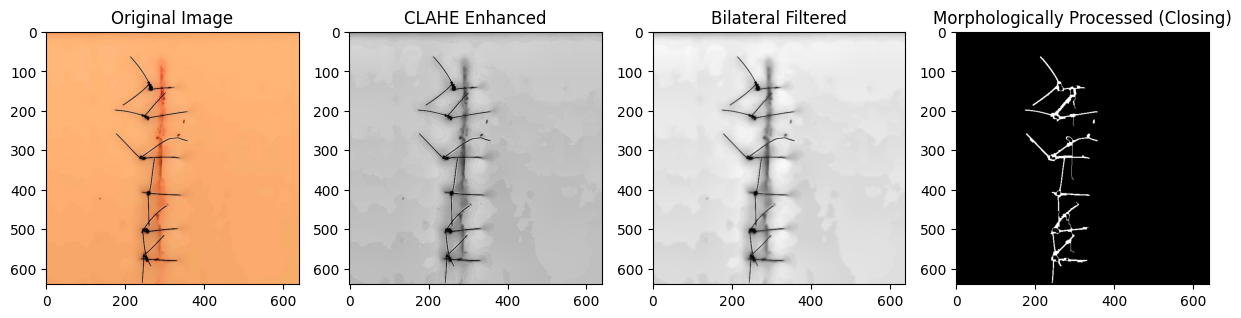

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the image
image_path = r'C:\Users\shaki\Documents\VSCode\ML Based Suture Pad Analysis\ML-based-suture-pad-analysis\data\enhanced_images_all\train\images\s_img_1_jpg.rf.0075d46b167fde030f059bad0c0b0529.jpg'

# Check if the image exists and is loaded
if not os.path.exists(image_path):
    print(f"Error: Image at {image_path} not found!")
else:
    image = cv2.imread(image_path)
    
    if image is None:
        print(f"Error: Failed to load image at {image_path}")
    else:
        # Step 1: Convert to Grayscale
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Step 2: Contrast Enhancement (CLAHE)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
        enhanced_image = clahe.apply(gray_image)

        # Step 3: Noise Reduction (Bilateral Filter)
        bilateral_filtered = cv2.bilateralFilter(enhanced_image, d=9, sigmaColor=75, sigmaSpace=75)

        # Step 4: Edge Detection (Canny)
        edges = cv2.Canny(bilateral_filtered, threshold1=50, threshold2=150)

        # Step 5: Morphological Operation (Closing to fill gaps)
        kernel = np.ones((5, 5), np.uint8)
        morph_image = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel)

        # Display the results step by step
        plt.figure(figsize=(15, 5))

        plt.subplot(1, 4, 1)
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        plt.title('Original Image')

        plt.subplot(1, 4, 2)
        plt.imshow(enhanced_image, cmap='gray')
        plt.title('CLAHE Enhanced')

        plt.subplot(1, 4, 3)
        plt.imshow(bilateral_filtered, cmap='gray')
        plt.title('Bilateral Filtered')

        plt.subplot(1, 4, 4)
        plt.imshow(morph_image, cmap='gray')
        plt.title('Morphologically Processed (Closing)')

        plt.show()
